Есакова Елизавета Михайловна

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from transformers import AutoModel, pipeline
import torch
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding)
from transformers import TrainerCallback
from sklearn.metrics import accuracy_score, f1_score
from datasets import Dataset

In [ ]:
print(f"GPU доступен: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU доступен: True
GPU: Tesla T4


# Беру тот же датасет,

In [ ]:
ROOT_PATH = "/content/drive/MyDrive/text/laba2/reviews.csv"

try:
    from google.colab import drive
    drive.mount('/content/drive')
except:
    print("Google Drive уже смонтирован или монтирование не требуется.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---

## Лабораторная 3. Трансформеры и большие языковые модели

**Про что:** большие языковые модели (7) · архитектура трансформера (8).

> Нужна будет GPU (Google Colab бесплатного уровня вроде ещё доступен), ну либо попробуйте небольшую модель, работающую на CPU.

---

### Часть 1 - Механизм внимания: разобрать изнутри (25%)

1. **Self-attention вручную на NumPy.** Реализуйте одну голову self-attention:

   Дано: матрица Q, K, V размером (seq_len × d_k).
   
   Формула: `Attention(Q, K, V) = softmax(Q @ K.T / sqrt(d_k)) @ V`

   Шаги:
   - Задайте последовательность из 4 слов, например `["I", "love", "NLP", "!"]`.
   - Для каждого слова задайте случайный вектор-эмбеддинг размерностью 8.
   - Задайте случайные матрицы весов W_Q, W_K, W_V и получите Q, K, V.
   - Вычислите матрицу весов внимания и итоговые векторы.

2. Визуализируйте матрицу весов внимания в виде **тепловой карты** (heatmap). Строки - queries, столбцы - keys. Какой токен в вашем примере получил больше всего внимания?

3. Ответьте письменно: зачем нужно делить на sqrt(d_k) перед softmax? Что произойдёт без этого деления при большой размерности?

---

Матрица весов внимания:
 [[0.    0.343 0.007 0.649]
 [0.    0.    0.999 0.001]
 [0.    0.952 0.    0.048]
 [1.    0.    0.    0.   ]]


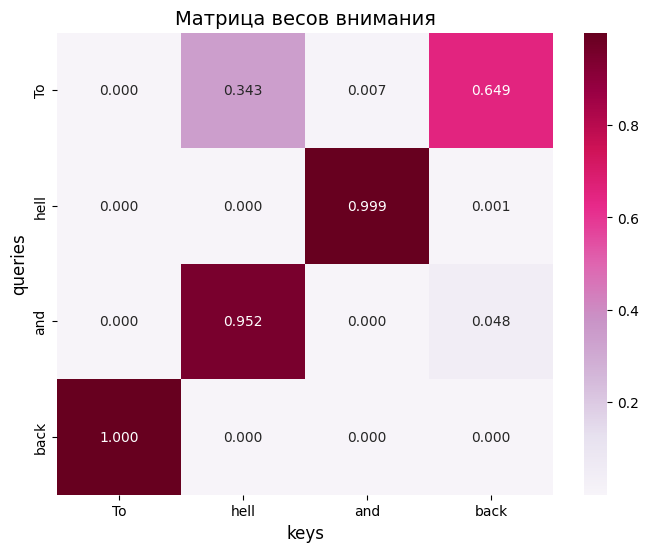

Токен 'To' получил внимания: 1.000
Токен 'hell' получил внимания: 1.295
Токен 'and' получил внимания: 1.006
Токен 'back' получил внимания: 0.698

Изначальное представление для каждого слова:
Слово 'To': [-0.417 -0.056 -2.136  1.64  -1.793 -0.842  0.503 -1.245]
Слово 'hell': [-1.058 -0.909  0.551  2.292  0.042 -1.118  0.539 -0.596]
Слово 'and': [-0.019  1.175 -0.748  0.009 -0.878 -0.156  0.257 -0.989]
Слово 'back': [-0.339 -0.236 -0.638 -1.188 -1.421 -0.153 -0.269  2.231]


Итоговые векторы для каждого слова:
Слово 'To': [-0.324  0.383  1.537 -2.045 -1.518  1.802 -0.98  -1.096]
Слово 'hell': [ 6.006  1.551  2.317 -4.076 -0.638 -2.103 -1.395 -0.346]
Слово 'and': [ 0.631 -0.21  -5.232  1.767  0.024 -0.495  0.743  1.857]
Слово 'back': [ 3.964  2.469 -0.309 -5.662 -3.161 -3.411 -0.448  1.133]


In [ ]:
np.random.seed(2)

words = ["To", "hell", "and", "back"]
seq_len = len(words)

d_model = 8
d_k = 8

X = np.random.randn(seq_len, d_model)

W_Q = np.random.randn(d_model, d_k)
W_K = np.random.randn(d_model, d_k)
W_V = np.random.randn(d_model, d_k)

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / np.sum(e_x, axis=-1, keepdims=True)

attweights = softmax(Q @ K.T / np.sqrt(d_k))

AttentionQVK = attweights @ V

print("Матрица весов внимания:\n", attweights.round(3))

plt.figure(figsize=(8, 6))

sns.heatmap(
    attweights,
    annot=True,
    cmap='PuRd',
    xticklabels=words,
    yticklabels=words,
    fmt=".3f"
)

plt.xlabel('keys', fontsize=12)
plt.ylabel('queries', fontsize=12)
plt.title('Матрица весов внимания', fontsize=14)
plt.show()

attention_received = attweights.sum(axis=0)

for i, word in enumerate(words):
    print(f"Токен '{word}' получил внимания: {attention_received[i]:.3f}")

print("\nИзначальное представление для каждого слова:")
for i, word in enumerate(words):
    print(f"Слово '{word}': {np.round(X[i], 3)}")
print()

print("\nИтоговые векторы для каждого слова:")
for i, word in enumerate(words):
    print(f"Слово '{word}': {np.round(AttentionQVK[i], 3)}")

Мы созлаем матрицу, размерностью из 4 строк (для каждого слова) и 8 столбцов (потому что эмбеддинг размера 8)

Теперь мы делаем матрицы весов:

Входные данные умножаются на три разные матрицы весов, чтобы получить три новых представления для каждого токена


*   Q (Query / Запрос) - то что ищет текущий токен
*   K (Key / Ключ) - значение токена, которыое показывает что он предлагает(как его можно описать)
*   V (Value / Значение) - реальный смысл слова, который мы заберем, если совпадение будет хорошим

то есть мы берем Q и сравниваем его со всеми K. Если они похожи, то значит важны друг для друга и в зависимости от важности мы берем V.

мы создаем W_Q, W_K, W_V чтобы как раз и создать Q, K и V. Эти матрицы преобразуют входные данные X в представления, необходимые для вычисления весов внимания

потом мы начинаем искать оценки схожести: мы умнажаем Q на транспонированную матрицу K, чтобы понять, на сколько они похожи. Чем выше значение, тем сильнее слова похожи.

по итогу наша матрица attweights показывает долю внимания, которое каждое слово(строка) уделяет каждому другому слову(столбец)

Долю внимания мы получаем суммируя значения по столбцам, потому что чтобцы это ключи, и суммируя значения мы получаем то, сколько внимание слово получило от остальных слов.

в задании была дана формула Attention(Q, K, V) = softmax(Q @ K.T / sqrt(d_k)) @ V

у меня этим является переменная AttentionQVK:

attweights = softmax(Q @ K.T / np.sqrt(d_k))

AttentionQVK = attweights @ V

# Среди моих слов больше всего внимания получил токен 'hell', потому что получил внимание от слов 'to' и ' and'. Но результат абсолютно случайный, так как эмбеддинги мы заполняем рандомно.

# зачем нужно делить на sqrt(d_k) перед softmax? Что произойдёт без этого деления при большой размерности?


Это надо делать для стабилизации процесса обучения.

В начале обучения эмбеддинги инициализируются случайными числами со средним значением 0 и дисперсией (разбросом) 1. По правилам теории вероятностей, если мы перемножаем две такие случайные величины, дисперсия их произведения тоже равна 1.

А мы складываем d_k(у нас 8) таких произведений. Дисперсия суммы независимых величин равна сумме их дисперсий, значит дисперсия итоговой суммы тоже будет 8.

Функция софтмакс:

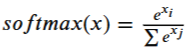

Получается, что если значения перед софтмакс будут слишком большими, то она будет выдавать неравномерные значения - для больших почти 1, а для других почти 0. Поэтому Деление на sqrt(d_k) масштабирует значения обратно к дисперсии, равной 1.

Без этого маштабирования с неравномерными значениями в матрице scores градиент функции софтмакс стремится к нулю. Это вызовет проблему исчезающих градиентов, из-за которой веса матриц перестанут обновляться, и модель не сможет обучаться

---

### Часть 2 - Работа с предобученными моделями (50%)

4. Загрузите предобученную модель через HuggingFace `transformers`. Выберите что-нибудь:
   - **Для английского текста:** `bert-base-uncased` (понимание текста)  или `gpt2` (генерация).
   - **Для русского текста:** не шарю, найдите что-нибудь / спросите у гпт)

5. **Токенизация BPE.** Используйте токенайзер выбранной модели:
   ```python
   from transformers import AutoTokenizer
   tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
   tokens = tokenizer("The quick brown fox", return_tensors="pt")
   ```
   - Токенизируйте 5–6 предложений. Для каждого выведите список токенов (именно строки).
   - Найдите примеры, где одно слово разбивается на несколько субтокенов. Почему так происходит? Чем это лучше обычной словарной токенизации?

6. **Для BERT-подобных моделей - предсказание маскированного токена:**
   ```python
   from transformers import pipeline
   fill_mask = pipeline("fill-mask", model="bert-base-uncased")
   fill_mask("The capital of France is [MASK].")
   ```
   - Проведите эксперимент с 5–7 предложениями с [MASK].
   - Выведите топ-5 предсказаний для каждого. В каких случаях модель угадывает правильно, а в каких - ошибается? Объясните одну интересную ошибку.

7. **Для GPT-подобных моделей - генерация текста:**
   ```python
   from transformers import pipeline
   generator = pipeline("text-generation", model="gpt2")
   generator("Once upon a time", max_length=60)
   ```
   - Сгенерируйте продолжения для 3 разных prompt'ов.
   - Попробуйте стратегии: greedy (`do_sample=False`), top-k (`top_k=50`), nucleus (`top_p=0.9`).
   - Как меняется текст при разных стратегиях? Какая кажется вам лучшей и почему?

8. **Контекстные эмбеддинги.** Возьмите слово с несколькими значениями, например `"bank"`. Составьте 6–8 предложений, где оно употребляется в разных смыслах. Извлеките эмбеддинги этого слова из последнего слоя BERT и визуализируйте через t-SNE. Разделяются ли два значения в пространстве?

---

In [ ]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

sentences = [
    "I want to break free.",
    "I'm happier than usual",
    "And I love him like nobody else can.",
    "Dancin' is what to do.",
    "No one's gonna save you now so you better save yourself.",
    "Tell me why am I emotional when I knew it from the start?",
    "The felidae sat on the mat"]

print("Примеры токенизации\n")
for sent in sentences:
    tokens = tokenizer.tokenize(sent)
    print(f"Предложение: {sent}")
    print(f"Токены: {tokens}")
    print(f"Сколько токенов: {len(tokens)}\n")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Примеры токенизации

Предложение: I want to break free.
Токены: ['i', 'want', 'to', 'break', 'free', '.']
Сколько токенов: 6

Предложение: I'm happier than usual
Токены: ['i', "'", 'm', 'happier', 'than', 'usual']
Сколько токенов: 6

Предложение: And I love him like nobody else can.
Токены: ['and', 'i', 'love', 'him', 'like', 'nobody', 'else', 'can', '.']
Сколько токенов: 9

Предложение: Dancin' is what to do.
Токены: ['dan', '##cin', "'", 'is', 'what', 'to', 'do', '.']
Сколько токенов: 8

Предложение: No one's gonna save you now so you better save yourself.
Токены: ['no', 'one', "'", 's', 'gonna', 'save', 'you', 'now', 'so', 'you', 'better', 'save', 'yourself', '.']
Сколько токенов: 14

Предложение: Tell me why am I emotional when I knew it from the start?
Токены: ['tell', 'me', 'why', 'am', 'i', 'emotional', 'when', 'i', 'knew', 'it', 'from', 'the', 'start', '?']
Сколько токенов: 14

Предложение: The felidae sat on the mat
Токены: ['the', 'fe', '##lidae', 'sat', 'on', 'the', 'mat']
С

BERT использует алгоритм WordPiece, который разбивает слова на более мелкие части. Две решетки ## означают, что токен является продолжением предыдущего

Как видно в моем четвертом предложении, там слово Dancin разбилось на dan и cin, или как в последнем предложении слово felidae разбилось на fe и lidae.

Это делается для того, чтобы модель могла эффективно работать с любым текстом, не перегружая память и понимая морфологию языка(вдруг в тексте редкое слово или опечатка, а так модель по знакомым частям может понять смысл и не терять информацию)

In [ ]:
fill_mask = pipeline("fill-mask", model="bert-base-uncased")

sentences = [
    "The sky is [MASK].",
    "The cat sat on the [MASK].",
    "He is very [MASK] and always smiles.",
    "The opposite of hot is [MASK].",
    "He drives a red [MASK] to work.",
    "In autumn, birds fly away to [MASK].",
    "The car has [MASK] wheels."]


for sentence in sentences:
    print(f"\nПредложение: {sentence}")
    predictions = fill_mask(sentence)

    print("Предсказания:")
    for pred in predictions[:5]:
        print(f" {pred['sequence']} ({pred['score']:.7f})")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Предложение: The sky is [MASK].
Предсказания:
 the sky is clear. (0.2009678)
 the sky is blue. (0.1899098)
 the sky is dark. (0.1326139)
 the sky is gray. (0.0625143)
 the sky is black. (0.0546007)

Предложение: The cat sat on the [MASK].
Предсказания:
 the cat sat on the floor. (0.3144574)
 the cat sat on the bed. (0.1190235)
 the cat sat on the couch. (0.1069601)
 the cat sat on the sofa. (0.0603262)
 the cat sat on the ground. (0.0550822)

Предложение: He is very [MASK] and always smiles.
Предсказания:
 he is very kind and always smiles. (0.0870769)
 he is very handsome and always smiles. (0.0739404)
 he is very friendly and always smiles. (0.0466623)
 he is very quiet and always smiles. (0.0428056)
 he is very sweet and always smiles. (0.0419534)

Предложение: The opposite of hot is [MASK].
Предсказания:
 the opposite of hot is hot. (0.3915480)
 the opposite of hot is cold. (0.3485068)
 the opposite of hot is cool. (0.0228803)
 the opposite of hot is warm. (0.0080017)
 the opposit

Модель BERT хорошо распознавании известные факты или предсказывает логичные продолжения на основе частоты паттернов, то есть она анализирует вероятность, а не понимает смысл.

Поэтому в примере 3 где надо найти антонимом, на первое место вывели то же слово 'hot', а только на второе 'cold' - модель не анализирует логически само предложения, что мы дали. Модель просто повторила слово, которое чаще всего было в похожих фразах или рядом с этими словами.

Еще забавно то, что в предложении 'у машины есть четыре колеса' модель выдала первым правильный ответ, но почему-то в топ 5 вывелось, что встречаются и 8 колес. Хотя я поискала и у грузовых машин 6 колес при среднем размере, а 10-12 у тяжелых еврофур. По 8 колес не было. 8 колес встречается в специализированнной техники и военном оборудовании.

# Теперь я взяла слово 'match' со значениями игрового матча, спичка и совместимость(на сколько что-то подходит друг другу)

In [ ]:
sentences = [
    # игровой матч
    "The volleyball match ended in a draw.",
    "We watched an exciting tennis match last night.",
    "The boxing match was brutal and intense.",

    # спичка
    "He struck a match to light the candle.",
    "She used a match to start the campfire.",

    # на сколько что-то подходит друг другу
    "The colors are a perfect match for the room.",
    "They are a great match for each other."]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Предложение: 'The volleyball match ended in a draw.'
Категория: Спорт
Токены: ['the', 'volleyball', 'match', 'ended', 'in', 'a', 'draw', '.']

Предложение: 'We watched an exciting tennis match last night.'
Категория: Спорт
Токены: ['we', 'watched', 'an', 'exciting', 'tennis', 'match', 'last', 'night', '.']

Предложение: 'The boxing match was brutal and intense.'
Категория: Спорт
Токены: ['the', 'boxing', 'match', 'was', 'brutal', 'and', 'intense', '.']

Предложение: 'He struck a match to light the candle.'
Категория: Спичка
Токены: ['he', 'struck', 'a', 'match', 'to', 'light', 'the', 'candle', '.']

Предложение: 'She used a match to start the campfire.'
Категория: Спичка
Токены: ['she', 'used', 'a', 'match', 'to', 'start', 'the', 'camp', '##fire', '.']

Предложение: 'The colors are a perfect match for the room.'
Категория: Соответствие
Токены: ['the', 'colors', 'are', 'a', 'perfect', 'match', 'for', 'the', 'room', '.']

Предложение: 'They are a great match for each other.'
Категория: С

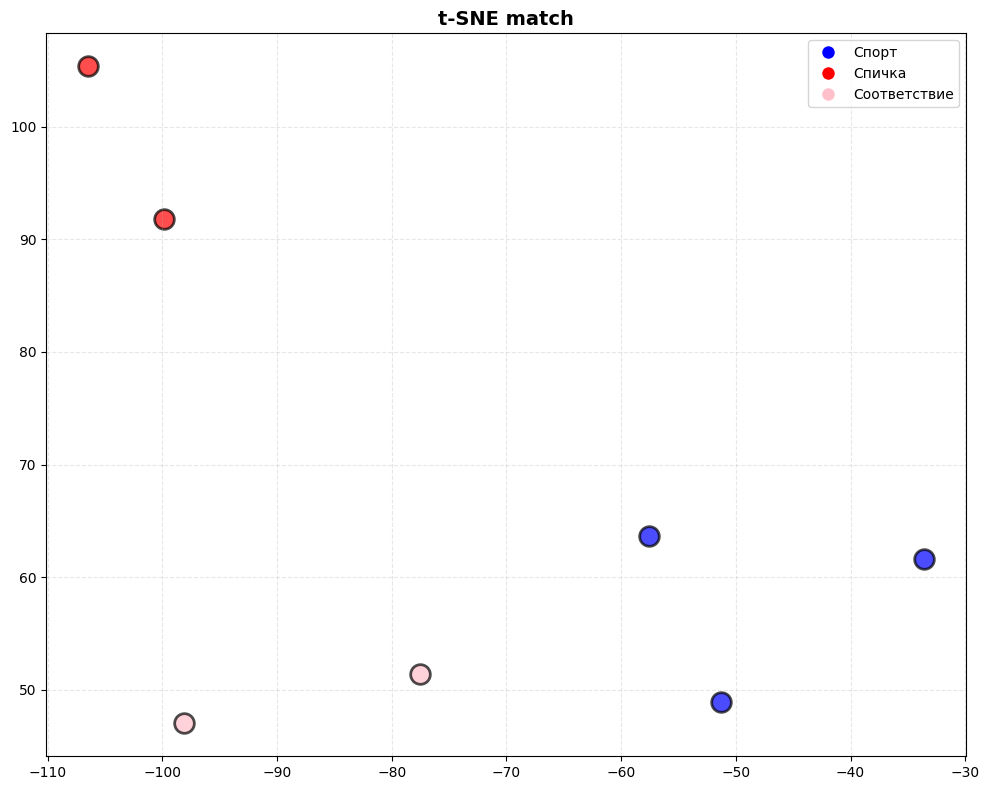

In [ ]:
model = AutoModel.from_pretrained(model_name)
model.eval()

embeddings = []
labels = []
categories = []

for sent in sentences:
    inputs = tokenizer(sent, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    hidden_states = outputs.last_hidden_state[0]
    tokens = tokenizer.tokenize(sent)

    try:
        match_idx = tokens.index("match")
        match_idx += 1
    except ValueError:
        match_idx = next(i for i, t in enumerate(tokens) if "match" in t) + 1

    word_embedding = hidden_states[match_idx, :].numpy()
    embeddings.append(word_embedding)

    sent_lower = sent.lower()
    if "volleyball" in sent_lower or "tennis" in sent_lower or "boxing" in sent_lower:
        labels.append("Спорт")
        categories.append("Спорт")
    elif "struck" in sent_lower or "light" in sent_lower or "campfire" in sent_lower:
        labels.append("Спичка")
        categories.append("Спичка")
    elif "perfect" in sent_lower or "colors" in sent_lower or "great match" in sent_lower:
        labels.append("Соответствие")
        categories.append("Соответствие")
    else:
        print(f"Не удалось определить категорию для: '{sent}'")
        continue

    print(f"Предложение: '{sent}'")
    print(f"Категория: {labels[-1]}")
    print(f"Токены: {tokens}\n")

print("Применяем t-SNE")
embeddings_array = np.array(embeddings)
tsne = TSNE(n_components=2, random_state=2, perplexity=min(3, len(embeddings)-1))
embeddings_2d = tsne.fit_transform(embeddings_array)

plt.figure(figsize=(10, 8))
colors = {
    "Спорт": "blue",
    "Спичка": "red",
    "Соответствие": "pink"}

for i, (x, y) in enumerate(embeddings_2d):
    category = categories[i]
    color = colors[category]
    plt.scatter(x, y, color=color, s=200, alpha=0.7, edgecolors='black', linewidth=2)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Спорт'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Спичка'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='pink', markersize=10, label='Соответствие'),]

plt.legend(handles=legend_elements, loc='best', fontsize=10)

plt.title("t-SNE match", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# По итогу эмбеддинги слова "match' четко разделяются в пространстве в зависимости от контекста

Модель читает предложение целиком, а код находит в её внутренних слоях именно тот числовой вектор, который соответствует слову "match" в этом конкретном предложении.

Как видно на графике,match получает разные векторные представления в зависимости от предложения.

---

### Часть 3 - Fine-tuning BERT на задаче классификации (25%)

9. Дообучите BERT (или RuBERT) на задаче классификации из Лабораторной 2. Используйте `AutoModelForSequenceClassification`:

   ```python
   from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments

   model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
   ```

   Параметры обучения: 2–3 эпохи, lr = 2e-5, batch_size = 16, max_length = 128.

10. Постройте графики train/eval loss. Вычислите accuracy и F1 на тесте.

11. Добавьте результат в итоговую таблицу из Лабораторной 2. Сравните все методы:

    | Метод | Test Accuracy |
    |---|---|
    | Логистическая регрессия (TF-IDF) | |
    | Нейросеть + GloVe | |
    | Fine-tuned BERT | |

    Какой прирост точности даёт переход к BERT? Всегда ли он оправдан? Назовите ситуации, когда проще ограничиться TF-IDF + логистической регрессией.


In [ ]:
df = pd.read_csv(ROOT_PATH, sep='\t')

df['label'] = df['sentiment'].map({'negative': 0, 'neautral': 1, 'positive': 2})

print(df['sentiment'].unique())
print(df['sentiment'].value_counts())

['negative' 'neautral' 'positive']
sentiment
negative    30000
neautral    30000
positive    30000
Name: count, dtype: int64


In [ ]:
print(f"Распределение меток:\n{df['label'].value_counts().sort_index()}")

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=2,
    stratify=df['label'])

print(f"Тренировочная: {len(train_df)}, Тестовая: {len(test_df)}")

train_dataset = Dataset.from_pandas(train_df[['review', 'label']])
test_dataset = Dataset.from_pandas(test_df[['review', 'label']])

Распределение меток:
label
0    30000
1    30000
2    30000
Name: count, dtype: int64
Тренировочная: 72000, Тестовая: 18000


In [ ]:
model_name = "DeepPavlov/rubert-base-cased"  # для русского текста
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples["review"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

tokenized_train = tokenized_train.remove_columns(["review"])
tokenized_test = tokenized_test.remove_columns(["review"])

tokenized_train.set_format("torch")
tokenized_test.set_format("torch")

Map:   0%|          | 0/72000 [00:00<?, ? examples/s]

Map:   0%|          | 0/18000 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_name,
                                                            num_labels=3)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro"),
        "f1_weighted": f1_score(labels, predictions, average="weighted")}

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those par

In [ ]:
training_args = TrainingArguments(
    output_dir="./results_bert_sentiment",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    report_to="none",
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
)

In [ ]:
class EpochMetricsPrinter(TrainerCallback):
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is not None:
            epoch = int(metrics.get("epoch", state.epoch))
            acc = metrics.get("eval_accuracy", None)
            f1 = metrics.get("eval_f1_macro", None)
            loss = metrics.get("eval_loss", None)

            print(f"Эпоха {epoch} завершена | "
                  f"Eval Loss: {loss:.4f} | "
                  f"Accuracy: {acc:.4f} | "
                  f"F1-macro: {f1:.4f}")

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
    callbacks=[EpochMetricsPrinter()])

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.534329,0.530538,0.764944,0.769277,0.769277
2,0.471201,0.524538,0.773167,0.773602,0.773602
3,0.379277,0.578073,0.770222,0.772269,0.772269


Эпоха 1 завершена | Eval Loss: 0.5305 | Accuracy: 0.7649 | F1-macro: 0.7693


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Эпоха 2 завершена | Eval Loss: 0.5245 | Accuracy: 0.7732 | F1-macro: 0.7736


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Эпоха 3 завершена | Eval Loss: 0.5781 | Accuracy: 0.7702 | F1-macro: 0.7723


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=13500, training_loss=0.4703486694053367, metrics={'train_runtime': 1972.9588, 'train_samples_per_second': 109.48, 'train_steps_per_second': 6.843, 'total_flos': 1.4208124557312e+16, 'train_loss': 0.4703486694053367, 'epoch': 3.0})

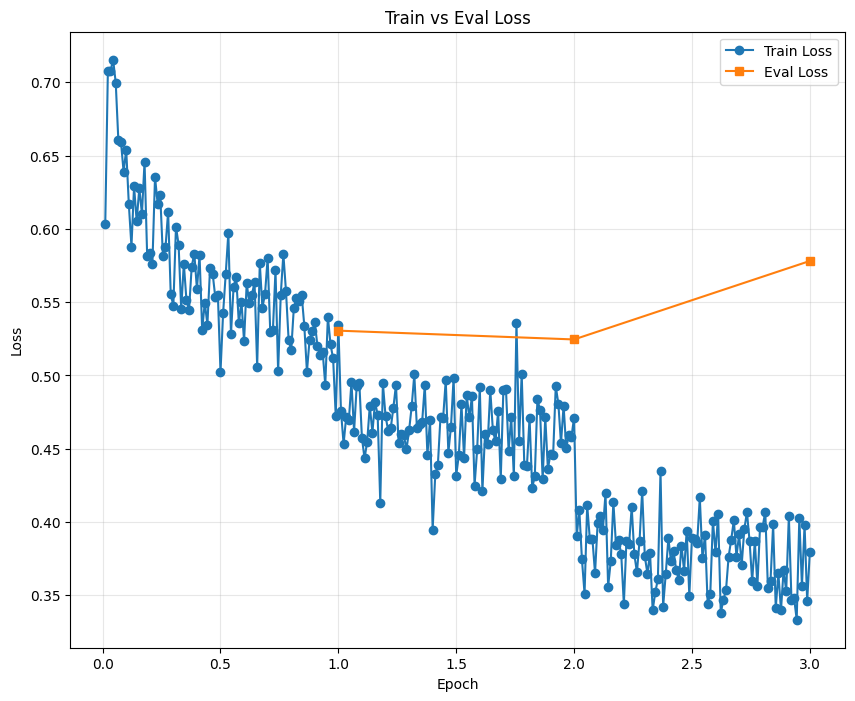

In [ ]:
log_history = trainer.state.log_history

train_epochs = [log["epoch"] for log in log_history if "loss" in log and "eval_loss" not in log]
train_losses = [log["loss"] for log in log_history if "loss" in log and "eval_loss" not in log]

eval_epochs = [log["epoch"] for log in log_history if "eval_loss" in log]
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]

plt.figure(figsize=(10, 8))
plt.plot(train_epochs, train_losses, 'o-', label='Train Loss')
plt.plot(eval_epochs, eval_losses, 's-', label='Eval Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Eval Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
results = trainer.evaluate(eval_dataset=tokenized_test)
print(f"Test Accuracy: {results['eval_accuracy']:.4f}")
print(f"Test F1 (macro): {results['eval_f1_macro']:.4f}")
print(f"Test F1 (weighted): {results['eval_f1_weighted']:.4f}")

Эпоха 3 завершена | Eval Loss: 0.5245 | Accuracy: 0.7732 | F1-macro: 0.7736


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,F1 Weighted
0.379277,0.524538,3,0.773167,0.773602,0.773602


Test Accuracy: 0.7732
Test F1 (macro): 0.7736
Test F1 (weighted): 0.7736


Это итоговая таблица со второй лабы, я взяла значения из нее

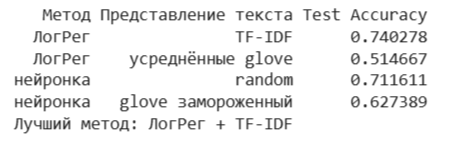

In [ ]:
tabl = pd.DataFrame({
    'Метод': ['ЛогРег+ TF-IDF', 'нейронка+Glove', 'BERT'],
    'Точность': [f'0.7403', f'0.6274', f'{results['eval_accuracy']:.4f}']})
print(tabl.to_string(index=False))

print('Прирост к точности: ', 0.7732-0.7403)

         Метод Точность
ЛогРег+ TF-IDF   0.7403
нейронка+Glove   0.6274
          BERT   0.7732
Прирост к точности:  0.03290000000000004


По итогу прирост точности по сравнению с прошлой лучшей моделью не такой большой, всего 0.033.

Несмотря на то, что BERT показал лучший результат, это не значит что он гораздо лучше. Для обучения модели мне потребовалось полчаса, когда как TF-IDF с лог регрессией обучилась за несколько минут.

На CPU берт может обучаться десятки часов(я сначала попробовала обучить ее там, мне показало, что мне надо 51 час. Потом я вспомнила, что надо переключиться на GPU и все обучилось уже за полчаса). А на моем слабом ноутбуке Тф-идф обучалась очень быстро.

Так что иногда проще обойтись без Берт:

*   если мало данных, потому что на малом объеме данных модель может переобучиться (она просто может запомнить выборку, а не ее закономерности)
*   если нужно очень быстро делать предсказания
*   если для определения класса достаточно наличия определенных слов(например, определение спама по словам "купи" или "выгодно"), то TF-IDF будет удобнее
*   если нужны простые и понятные решения. В лог регрессии можно посмотреть, какие слова влияют на решение модели, и объяснить, почему она так классифицировала текст по весам признаков